# Phase 9: robustness of CM passive Clifford enhancements

This notebook measures how the exact and approximate CM-only passive logical gates behave under the same fixed-radius deformations used in Phase 8. Set `REGENERATE=True` to rerun the complete 3,200-evaluation experiment.

In [1]:
from pathlib import Path
import gzip, json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

HERE = Path.cwd().resolve()
CANDIDATES = (HERE, HERE.parent, HERE / 'passive-cliffords')
PROJECT = next(path for path in CANDIDATES if (path / 'src' / 'gkp_passive_cliffords').exists())
sys.path[:0] = [str(PROJECT/'src'), str(PROJECT.parent/'src')]
DATA, FIGURES = PROJECT/'data', PROJECT/'figures'
FIGURES.mkdir(exist_ok=True)
REGENERATE = False
if REGENERATE:
    subprocess.run([sys.executable, str(PROJECT/'scripts/generate_phase9_gate_robustness.py')], check=True, cwd=PROJECT)
    subprocess.run([sys.executable, str(PROJECT/'scripts/audit_phase9_precision.py')], check=True, cwd=PROJECT)
print('Project:', PROJECT.name)

Project: passive-cliffords


## Continuous logical-gate defect

For every logical action $a$, minimize over all CM automorphisms implementing it:

$$\delta_a(G)=\min_{U\mapsto a}\frac{1}{\sqrt{2g}}\left\|G^{-1/2}(U^TGU-G)G^{-1/2}\right\|_F.$$

The score below excludes the unavoidable logical image of $\{+I,-I\}$ and measures only the CM-enhanced actions:

$$R_\tau(G)=\frac{1}{|\mathcal I_{CM}\setminus\mathcal I_{gen}|}\sum_{a\notin\mathcal I_{gen}}e^{-(\delta_a/\tau)^2},\qquad\tau=0.02.$$

In [2]:
def load_json(name):
    path = DATA / name
    if path.exists(): return json.loads(path.read_text())
    with gzip.open(str(path) + '.gz', 'rt') as handle: return json.load(handle)
summary = pd.DataFrame(load_json('phase9_gate_robustness_summary.json'))
evaluations = pd.DataFrame(load_json('phase9_gate_robustness_evaluations.json'))
audits = pd.DataFrame(load_json('phase9_high_precision_audit.json'))
protocol = load_json('phase9_gate_robustness_protocol.json')
for frame in (summary, evaluations):
    frame['type'] = frame.polarization_type.apply(lambda x: '('+','.join(map(str,x))+')')
print(f'{len(summary)} searches, {len(evaluations)} joint gate/distance evaluations, {len(audits)} extremal audits')
pd.Series({'radii':protocol['radii'], 'tau':protocol['tau'], 'epsilons':protocol['epsilons'], 'queries/search':128})

25 searches, 3200 joint gate/distance evaluations, 50 extremal audits


radii                            [0.005, 0.01, 0.02, 0.05, 0.1]
tau                                                        0.02
epsilons          [1e-08, 0.0025, 0.005, 0.01, 0.02, 0.05, 0.1]
queries/search                                              128
dtype: object

## Baseline logical images

The enhancement column counts the logical actions present at the CM point beyond the complete generic $\{+I,-I\}$ image.

In [3]:
champions = summary.sort_values(['type','radius']).groupby('type',as_index=False).first()
champions['CM_only_actions'] = champions.logical_image_order-champions.generic_minimal_image_order
champions[['type','polarized_automorphism_order','logical_image_order','generic_minimal_image_order','CM_only_actions','cm_ell_squared']]

,type,polarized_automorphism_order,logical_image_order,generic_minimal_image_order,CM_only_actions,cm_ell_squared
0,"(1,1,2)",384,6,1,5,1.000000
1,"(1,1,3)",1296,24,2,22,1.154701
2,"(1,2,2)",384,48,1,47,1.000000
3,"(1,3)",24,24,2,22,0.816497
4,"(1,5)",4,4,2,2,0.539360


## Exact result

At tolerance $10^{-8}$, all nonzero generic deformations lose every exact CM-only logical action. Only the generic logical image survives.

In [4]:
exact_table = evaluations.groupby('type').agg(
    evaluations=('candidate_id','size'),
    maximum_exact_CM_only_actions=('exact_retained_enhanced_actions','max'),
    minimum_total_exact_actions=('exact_retained_logical_actions','min'),
    maximum_total_exact_actions=('exact_retained_logical_actions','max'),
)
display(exact_table)
assert evaluations.exact_retained_enhanced_actions.max()==0

,evaluations,maximum_exact_CM_only_actions,minimum_total_exact_actions,maximum_total_exact_actions
type,,,,
"(1,1,2)",640,0,1,1
"(1,1,3)",640,0,2,2
"(1,2,2)",640,0,1,1
"(1,3)",640,0,2,2
"(1,5)",640,0,2,2


## Approximate retention is strongly directional

At each radius, one Bayesian arm maximizes retention and another minimizes it. The gap measures how much the survival of approximate gates depends on deformation direction.

In [5]:
by_radius = summary.groupby('radius').agg(
    mean_best_retention=('overall_best_retention','mean'),
    mean_worst_retention=('overall_worst_retention','mean'),
    mean_best_direction_ell_ratio=('best_retention_ell_ratio','mean'),
    mean_worst_direction_ell_ratio=('worst_retention_ell_ratio','mean'),
).reset_index()
display(by_radius.style.format({c:'{:.6f}' for c in by_radius.columns if c!='radius'}))

,radius,mean_best_retention,mean_worst_retention,mean_best_direction_ell_ratio,mean_worst_direction_ell_ratio
0,0.005000,0.953364,0.875493,0.996162,0.994171
1,0.010000,0.839443,0.605564,0.992311,0.989424
2,0.020000,0.579197,0.184883,0.985295,0.979602
3,0.050000,0.196606,0.000811,0.960856,0.952520
4,0.100000,0.028553,0.000000,0.919405,0.904030


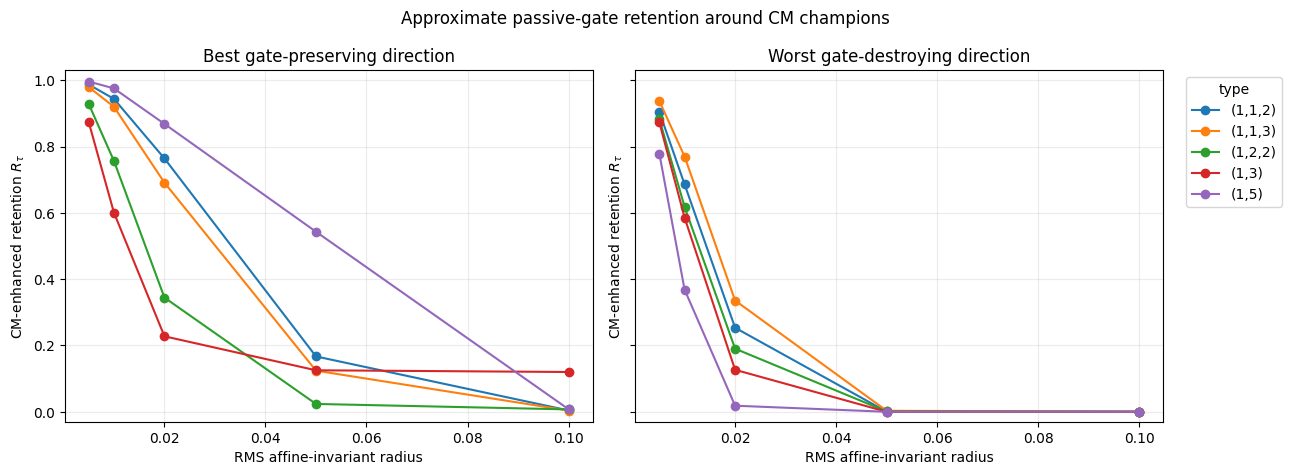

In [6]:
fig, axes = plt.subplots(1,2,figsize=(13,4.8),sharey=True)
for label, group in summary.groupby('type'):
    group=group.sort_values('radius')
    axes[0].plot(group.radius,group.overall_best_retention,marker='o',label=label)
    axes[1].plot(group.radius,group.overall_worst_retention,marker='o',label=label)
for ax,title in zip(axes,['Best gate-preserving direction','Worst gate-destroying direction']):
    ax.set(xlabel='RMS affine-invariant radius',ylabel=r'CM-enhanced retention $R_\tau$',title=title,ylim=(-.03,1.03))
    ax.grid(alpha=.25)
axes[1].legend(title='type',bbox_to_anchor=(1.03,1),loc='upper left')
fig.suptitle('Approximate passive-gate retention around CM champions')
fig.tight_layout()
fig.savefig(FIGURES/'phase9_radial_retention.png',dpi=180,bbox_inches='tight')
plt.show()

## Literal $\varepsilon$-passive counts

The next plot shows the fraction of CM-only logical actions with defect at most $\varepsilon=0.01$ in the best direction found.

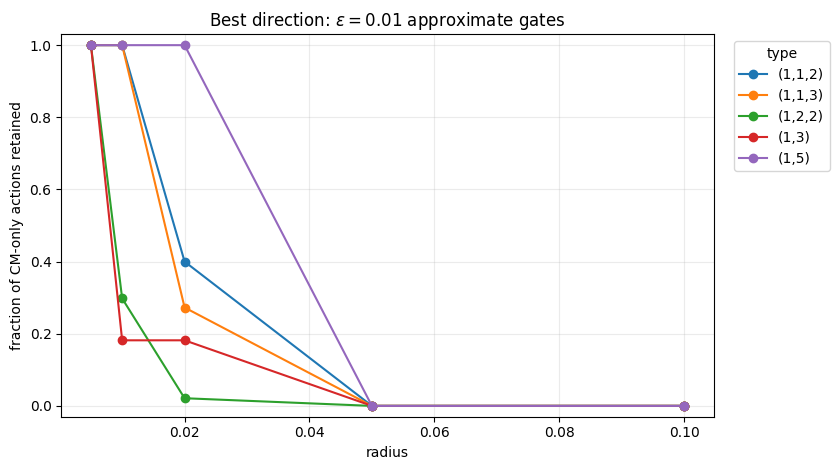

In [7]:
eps='0.01'
summary['enhanced_total']=summary.logical_image_order-summary.generic_minimal_image_order
summary['best_fraction_eps_001']=[d[eps]/n for d,n in zip(summary.best_retention_enhanced_epsilon_counts,summary.enhanced_total)]
fig,ax=plt.subplots(figsize=(8.5,4.8))
for label,group in summary.groupby('type'):
    group=group.sort_values('radius')
    ax.plot(group.radius,group.best_fraction_eps_001,marker='o',label=label)
ax.set(xlabel='radius',ylabel='fraction of CM-only actions retained',title=r'Best direction: $\varepsilon=0.01$ approximate gates',ylim=(-.03,1.03))
ax.grid(alpha=.25);ax.legend(title='type',bbox_to_anchor=(1.02,1),loc='upper left')
fig.tight_layout()
fig.savefig(FIGURES/'phase9_epsilon_gate_counts.png',dpi=180,bbox_inches='tight')
plt.show()

## Gate retention versus logical distance

Because every queried deformation also receives an exact $\ell^2$ calculation, we can test whether preserving gates competes with preserving error-correction distance.

Mean within-search Spearman correlation: 0.22815281084050537
Positive correlations: 22 of 25


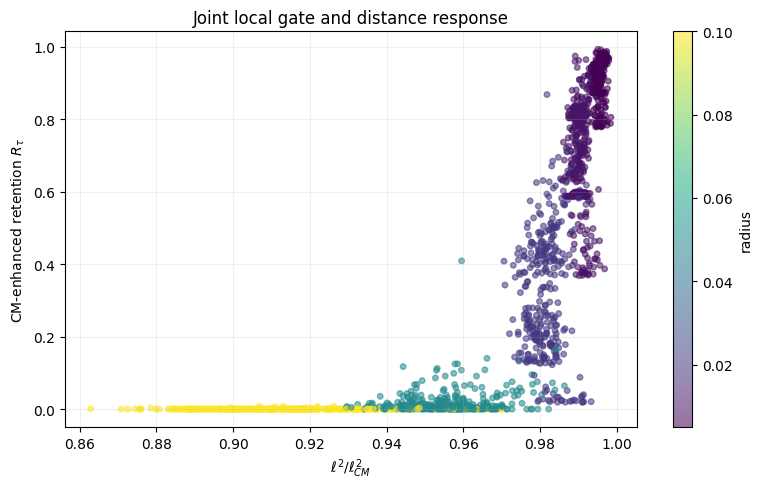

In [8]:
correlations=[]
for (candidate,radius),group in evaluations.groupby(['candidate_id','radius']):
    correlations.append({'candidate_id':candidate,'radius':radius,'spearman':spearmanr(group.retention_score,group.ell_ratio_to_cm).statistic})
corr=pd.DataFrame(correlations)
print('Mean within-search Spearman correlation:',corr.spearman.mean())
print('Positive correlations:',int((corr.spearman>0).sum()),'of',len(corr))
sample=evaluations.sample(min(1800,len(evaluations)),random_state=9)
fig,ax=plt.subplots(figsize=(8,5))
scatter=ax.scatter(sample.ell_ratio_to_cm,sample.retention_score,c=sample.radius,cmap='viridis',s=16,alpha=.55)
ax.set(xlabel=r'$\ell^2/\ell^2_{CM}$',ylabel=r'CM-enhanced retention $R_\tau$',title='Joint local gate and distance response')
ax.grid(alpha=.2);fig.colorbar(scatter,ax=ax,label='radius')
fig.tight_layout()
fig.savefig(FIGURES/'phase9_joint_gate_distance.png',dpi=180,bbox_inches='tight')
plt.show()

## Bayesian search effectiveness and validation

In [9]:
best_wins=int((summary.bayesian_best_retention>summary.sobol_best_retention+1e-12).sum())
worst_wins=int((summary.bayesian_worst_retention<summary.sobol_worst_retention-1e-12).sum())
worst_ties=int((np.abs(summary.bayesian_worst_retention-summary.sobol_worst_retention)<=1e-12).sum())
checks=pd.Series({
    'Bayesian best-retention wins':f'{best_wins}/25',
    'Bayesian worst-retention wins':f'{worst_wins}/25',
    'Bayesian worst-retention ties':f'{worst_ties}/25',
    'max radius error':summary.maximum_distance_error.max(),
    'max polarization residual':summary.maximum_polarization_residual.max(),
    'max log-volume residual':summary.maximum_log_volume_residual.max(),
    'max scalar/vectorized defect discrepancy':audits.maximum_scalar_vectorized_defect_discrepancy.max(),
    'max high-precision ell discrepancy':audits.ell_absolute_discrepancy.max(),
})
display(checks)
assert len(summary)==25 and len(evaluations)==3200 and len(audits)==50
assert evaluations.exact_retained_enhanced_actions.max()==0
assert summary.maximum_distance_error.max()<2.1e-11
assert audits.ell_absolute_discrepancy.max()<2e-12
print('All Phase-9 notebook checks passed.')

Bayesian best-retention wins                21/25
Bayesian worst-retention wins               11/25
Bayesian worst-retention ties                6/25
max radius error                              0.0
max polarization residual                     0.0
max log-volume residual                       0.0
max scalar/vectorized defect discrepancy      0.0
max high-precision ell discrepancy            0.0
dtype: object

All Phase-9 notebook checks passed.


## Interpretation

The extra CM passive Clifford actions are exact only on a special locus: every tested nonzero generic deformation reduces the exact image to the generic minimum. Nevertheless, small deformations can retain most CM-only actions approximately, and the retention depends strongly on direction. Gate-preserving directions also tend to preserve $\ell^2$, so the experiment shows mild local alignment rather than a simple gate-versus-distance tradeoff. This is numerical evidence about the known CM gate set, not an exhaustive classification of all automorphisms of every deformed metric.